# Optimización de las longitudes para los DC

Este codigo busca optimizar las longitudes de acoplo para tener un acoplo más parecido a lo que se busca, de manera que se aumenta o disminuye un poco esa longitud. Cabe resaltar que para realizar esta simulación modifiqué la librería upvfab_design_tools, de manera que, le puse los valores de la sección transversal a las guias de la librería, directamente modificandola. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


Primero hay que importar las librerias y definir los materiales que vamos a usar

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

Ahora creamos la estructura del acoplador direccional con los parámetros hallados en el código principal 

In [ ]:
# Parámetros 
wg_gap = 0.35 # Gap
wg_width = 450 * nm # Tamaño de las guias
L_pi_list = [43.464, 23.519, 27.68,  12.48,  32.077] # longitudes de acoplo

d = wg_width + wg_gap
wg_N = 2   # Numero de guias

# Definición del directinal coupler
m = DC_EME() # Definimos el directinal coupler

m.DC_wg_gap = wg_gap # le damos el gap
m.DC_wg_width = wg_width # le damos el ancho de las guias
m.DC_N_waveguides = wg_N

# se encuentran los modos de propagación
m.find_all_modes()

# se obtiene la longitud de batido
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/au/pic-upv-lab2_copy/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  81.77553055667276  µm


/home/au/pic-upv-lab2_copy/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


#### Acoplo de 50%

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/872 [00:00<?, ?it/s]

------- Pameters -------
MMI length 43.6140
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.1551
Total OUT power: 0.0321
Excess loss [dB] =  14.9376
------------------------
Power over OUTs:  ['0.0163', '0.0158']
Ratio over OUTs ['0.5088', '0.4912']


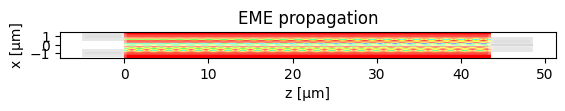

In [ ]:
# Le decimos el número de salidas y de entradas
m.n_IN = 2
m.n_OUT = 2

# Le agregamos una longitud que optimizar el acoplo
L_correct_1=0.15

m.L_MMI = L_pi_list[0]+L_correct_1 

# miramos como se propaga, obteniendo la potencia transmitida y ploteando su propagación
m.propagation()

#### Acoplo de 17%

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/476 [00:00<?, ?it/s]

------- Pameters -------
MMI length 23.7990
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.1551
Total OUT power: 0.0438
Excess loss [dB] =  13.5826
------------------------
Power over OUTs:  ['0.0364', '0.0075']
Ratio over OUTs ['0.8295', '0.1705']


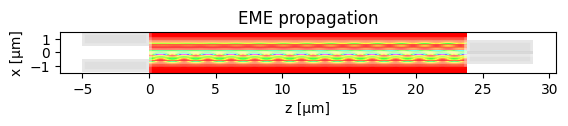

In [18]:
L_correct_2=0.28

m.L_MMI = L_pi_list[1]+L_correct_2 # Since we use the same library for propagation simulations of MMI and DC 
                        # some variables might be identified as "MMI". Sorry about that (: 
                        # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

#### Acoplo de 23%

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/559 [00:00<?, ?it/s]

------- Pameters -------
MMI length 27.9300
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.1551
Total OUT power: 0.0311
Excess loss [dB] =  15.0681
------------------------
Power over OUTs:  ['0.0239', '0.0072']
Ratio over OUTs ['0.7675', '0.2325']


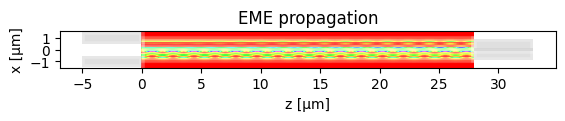

In [21]:
L_correct_3=0.25

m.L_MMI = L_pi_list[2]+L_correct_3 # Since we use the same library for propagation simulations of MMI and DC 
                        # some variables might be identified as "MMI". Sorry about that (: 
                        # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

#### Acoplo de 5%

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/244 [00:00<?, ?it/s]

------- Pameters -------
MMI length 12.2100
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.1551
Total OUT power: 0.0308
Excess loss [dB] =  15.1096
------------------------
Power over OUTs:  ['0.0293', '0.0015']
Ratio over OUTs ['0.9504', '0.0496']


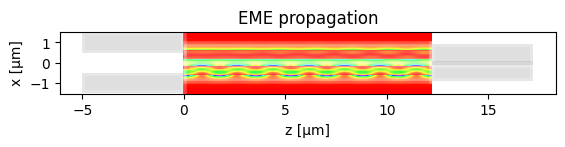

In [39]:
L_correct_4=-0.27

m.L_MMI = L_pi_list[3]+L_correct_4 # Since we use the same library for propagation simulations of MMI and DC 
                        # some variables might be identified as "MMI". Sorry about that (: 
                        # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

#### Acoplo de 30%

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/630 [00:00<?, ?it/s]

------- Pameters -------
MMI length 31.4770
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.1551
Total OUT power: 0.0308
Excess loss [dB] =  15.1083
------------------------
Power over OUTs:  ['0.0214', '0.0095']
Ratio over OUTs ['0.6932', '0.3068']


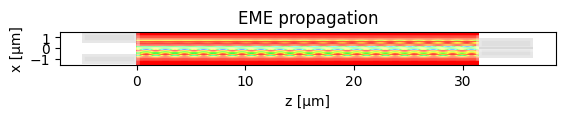

In [48]:
L_correct_5=-0.6

m.L_MMI = L_pi_list[4]+L_correct_5 # Since we use the same library for propagation simulations of MMI and DC 
                        # some variables might be identified as "MMI". Sorry about that (: 
                        # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()